# 504: Peak Warming vs Net-Zero CO2 Year

This notebook analyzes the relationship between peak warming (GSAT|ALL|peak) and the year of net-zero CO2 emissions.

In [1]:
import os
from pathlib import Path

import dotenv
import pandas as pd
import matplotlib.pyplot as plt
import yaml

dotenv.load_dotenv()

OUTPUT_FOLDER = Path(os.environ["OUTPUT_FOLDER"])

# Load IPCC color palette
with open("ipcc_colors.yml") as f:
    IPCC_COLORS = yaml.safe_load(f)

In [2]:
# Load 503 metrics
metrics_df = pd.read_csv(OUTPUT_FOLDER / "503_warming_metrics.csv")
print(f"Loaded {len(metrics_df):,} runs")

# Load cumulative net-negative CO2 and CH4 decline groups from 105
meta_105 = pd.read_csv(OUTPUT_FOLDER / "105_netzero_timings_cumnetnegco2.csv")
meta_105 = meta_105[["model", "scenario", "cumulative_netnegative_co2", "ch4_decline", "ch4_decline_group"]].copy()

# Merge with metrics_df
metrics_df = metrics_df.merge(meta_105, on=["model", "scenario"], how="left")
print(f"Merged metadata for {metrics_df['cumulative_netnegative_co2'].notna().sum():,} runs")

metrics_df.head()

Loaded 409,800 runs
Merged metadata for 409,800 runs


,Unnamed: 0,model,scenario,run_id,peak_year,GSAT|ALL|peak,GSAT|ALL|2100,GSAT|NonCO2_GHG|peak,GSAT|NonCO2_GHG|2100,GSAT|Residual|peak,...,GSAT|ALL|delta,GSAT|CO2_NZCO2|delta,GSAT|CO2_Negative|delta,GSAT|NonCO2_GHG|delta,GSAT|Residual|delta,year_netzero_co2,year_netzero_kyoto_ar6gwp100,cumulative_netnegative_co2,ch4_decline,ch4_decline_group
0,0,AIM/CGE 2.0,SSP1-19,0,2049,1.612907,1.411091,0.092336,-0.093244,-0.041236,...,-0.201816,-0.049494,-0.065621,-0.185580,0.098879,2058.0,2073.0,-135.79,261.96,High CH4 decline
1,1,AIM/CGE 2.0,SSP1-19,1,2093,2.592601,2.577173,0.438947,0.419883,-0.822595,...,-0.015427,0.025233,-0.024810,-0.019064,0.003215,2058.0,2073.0,-135.79,261.96,High CH4 decline
2,2,AIM/CGE 2.0,SSP1-19,2,2049,1.798363,1.577004,0.099817,-0.076595,0.046628,...,-0.221359,-0.027495,-0.069052,-0.176412,0.051601,2058.0,2073.0,-135.79,261.96,High CH4 decline
3,3,AIM/CGE 2.0,SSP1-19,3,2038,1.379944,1.074082,0.098739,-0.197705,0.052872,...,-0.305862,-0.069634,-0.052731,-0.296443,0.112946,2058.0,2073.0,-135.79,261.96,High CH4 decline
4,4,AIM/CGE 2.0,SSP1-19,4,2048,1.645092,1.396311,0.107123,-0.111821,-0.000573,...,-0.248781,-0.058318,-0.062936,-0.218945,0.091418,2058.0,2073.0,-135.79,261.96,High CH4 decline


In [3]:
# Calculate median and percentiles of GSAT|ALL|peak per scenario
scenario_stats = metrics_df.groupby(["model", "scenario"]).agg({
    "GSAT|ALL|peak": [
        lambda x: x.quantile(0.05),
        lambda x: x.quantile(0.33),
        "median",
        lambda x: x.quantile(0.67),
        lambda x: x.quantile(0.95)
    ],
    "GSAT|ALL|delta": "median",
    "GSAT|CO2_NZCO2|delta": "median",
    "year_netzero_co2": "first",
    "cumulative_netnegative_co2": "first",
    "ch4_decline": "first",
    "ch4_decline_group": "first"
}).reset_index()

# Flatten column names
scenario_stats.columns = ["model", "scenario", "peak_p05", "peak_p33", "peak_median", "peak_p67", "peak_p95",
                          "delta_all_median", "delta_co2_nzco2_median", 
                          "year_netzero_co2", "cumulative_netnegative_co2", "ch4_decline", "ch4_decline_group"]

print(f"Scenarios: {len(scenario_stats)}")
print(f"\nCH4 decline group value counts:")
print(scenario_stats["ch4_decline_group"].value_counts(dropna=False))
print(f"\nUnique values: {scenario_stats['ch4_decline_group'].unique()}")

Scenarios: 683

CH4 decline group value counts:
ch4_decline_group
Medium CH4 decline    237
High CH4 decline      234
Low CH4 decline       212
Name: count, dtype: int64

Unique values: ['High CH4 decline' 'Low CH4 decline' 'Medium CH4 decline']


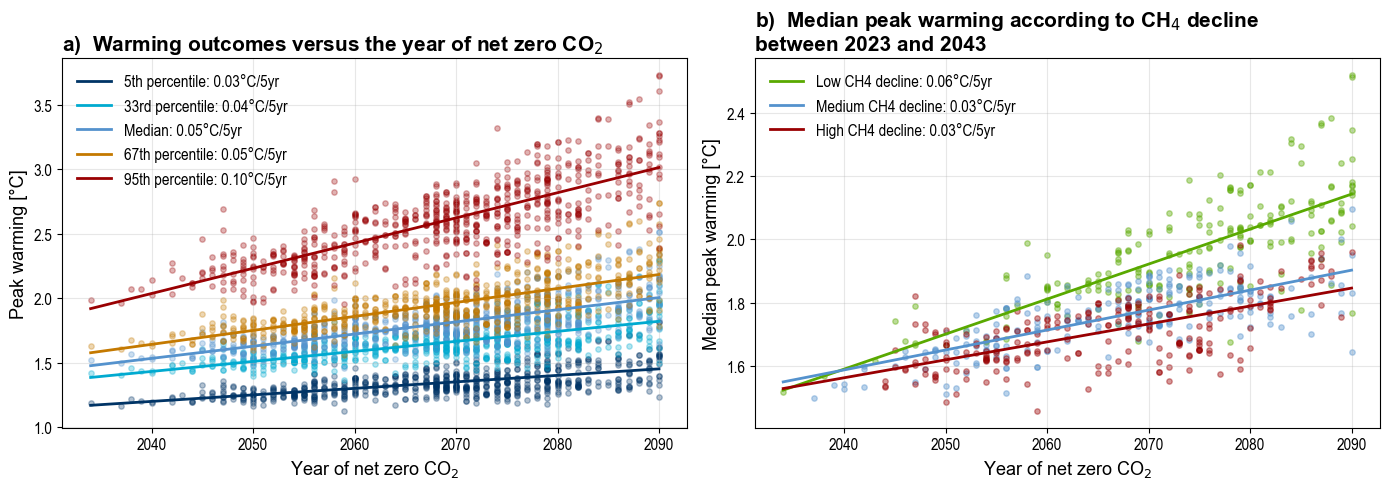

In [4]:
# Scatter plot: Peak warming vs net-zero CO2 year
# Panel 1: All percentiles (no CH4 grouping)
# Panel 2: Median only, grouped by CH4 decline
import numpy as np
import matplotlib.font_manager as fm

# Set up fonts
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.sans-serif'] = ['Arial']

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

# Filter for valid data
plot_data = scenario_stats.dropna(subset=["ch4_decline_group", "year_netzero_co2"]).copy()

x_all = plot_data["year_netzero_co2"].values
x_fit = np.linspace(plot_data["year_netzero_co2"].min(), plot_data["year_netzero_co2"].max(), 100)

# --- Panel 1: All percentiles, no CH4 grouping ---
ax1 = axes[0]

percentile_colors = {
    "peak_p05": "#003466",    # Dark Blue
    "peak_p33": "#00aad0",    # Warm Blue
    "peak_median": "#5492cd", # IPCC Blue
    "peak_p67": "#c47900",    # Warm Mustard
    "peak_p95": "#990002",    # Warm Red
}
percentile_labels = {
    "peak_p05": "5th percentile",
    "peak_p33": "33rd percentile",
    "peak_median": "Median",
    "peak_p67": "67th percentile",
    "peak_p95": "95th percentile",
}

for col in ["peak_p05", "peak_p33", "peak_median", "peak_p67", "peak_p95"]:
    y = plot_data[col].values
    hex_color = percentile_colors[col]
    label = percentile_labels[col]
    
    ax1.scatter(x_all, y, facecolors=hex_color, edgecolors=hex_color, alpha=0.3, s=15)
    
    valid = ~np.isnan(y)
    if valid.sum() > 1:
        slope, intercept = np.polyfit(x_all[valid], y[valid], 1)
        ax1.plot(x_fit, slope * x_fit + intercept, 
                color=hex_color, linewidth=2,
                label=f"{label}: {slope*5:.2f}°C/5yr")

ax1.set_xlabel("Year of net zero CO$_2$", fontname="Arial", fontsize=13)
ax1.set_ylabel("Peak warming [°C]", fontname="Arial", fontsize=13)
ax1.set_title("a)  Warming outcomes versus the year of net zero CO$_2$", loc="left", 
              fontname="Arial", fontsize=15, fontweight="bold")
ax1.legend(fontsize=12, loc="upper left", frameon=False, prop={"family": "Arial Narrow", "size": 12})
ax1.grid(alpha=0.3)
ax1.tick_params(axis='both', labelsize=12)
for label in ax1.get_xticklabels() + ax1.get_yticklabels():
    label.set_fontname("Arial Narrow")

# --- Panel 2: Median only, grouped by CH4 decline ---
ax2 = axes[1]

GROUP_COLORS = {
    "Low CH4 decline": "#59a900",      # Bright Green
    "Medium CH4 decline": "#5492cd",   # IPCC Blue
    "High CH4 decline": "#990002",     # Warm Red
}

for group in ["Low CH4 decline", "Medium CH4 decline", "High CH4 decline"]:
    subset = plot_data[plot_data["ch4_decline_group"] == group]
    x = subset["year_netzero_co2"].values
    y = subset["peak_median"].values
    hex_color = GROUP_COLORS[group]
    
    ax2.scatter(x, y, facecolors=hex_color, edgecolors=hex_color, alpha=0.4, s=15)
    
    valid = ~np.isnan(y)
    if valid.sum() > 1:
        slope, intercept = np.polyfit(x[valid], y[valid], 1)
        ax2.plot(x_fit, slope * x_fit + intercept, 
                color=hex_color, linewidth=2,
                label=f"{group}: {slope*5:.2f}°C/5yr")

ax2.set_xlabel("Year of net zero CO$_2$", fontname="Arial", fontsize=13)
ax2.set_ylabel("Median peak warming [°C]", fontname="Arial", fontsize=13)
ax2.set_title("b)  Median peak warming according to CH$_4$ decline\nbetween 2023 and 2043", loc="left",
              fontname="Arial", fontsize=15, fontweight="bold")
ax2.legend(fontsize=12, loc="upper left", frameon=False, prop={"family": "Arial Narrow", "size": 12})
ax2.grid(alpha=0.3)
ax2.tick_params(axis='both', labelsize=12)
for label in ax2.get_xticklabels() + ax2.get_yticklabels():
    label.set_fontname("Arial Narrow")

plt.tight_layout()

In [5]:
# Save figure in high resolution PNG and SVG formats
fig.savefig(OUTPUT_FOLDER / "504_peak_warming_vs_netzero.png", dpi=300, bbox_inches='tight')
fig.savefig(OUTPUT_FOLDER / "504_peak_warming_vs_netzero.svg", bbox_inches='tight')
print(f"Saved to {OUTPUT_FOLDER / '504_peak_warming_vs_netzero.png'}")
print(f"Saved to {OUTPUT_FOLDER / '504_peak_warming_vs_netzero.svg'}")

Saved to /Users/ganti/Documents/code/ar7_netzero_assessment/analysis/output/504_peak_warming_vs_netzero.png
Saved to /Users/ganti/Documents/code/ar7_netzero_assessment/analysis/output/504_peak_warming_vs_netzero.svg
